# <center>PROJECT-3. EDA + Feature Engineering. Соревнование на Kaggle

## 1.Введение

### КАКОЙ КЕЙС РЕШАЕМ?

Представьте, что вы работаете дата-сайентистом в компании Booking. Одна из проблем компании — это нечестные отели, которые накручивают себе рейтинг. Одним из способов обнаружения таких отелей является построение модели, которая предсказывает рейтинг отеля. Если предсказания модели сильно отличаются от фактического результата, то, возможно, отель ведёт себя нечестно, и его стоит проверить.

Датасет [hostel.cvs](https://drive.google.com/file/d/1Qj0iYEbD64eVAaaBylJeIi3qvMzxf2C_/view?usp=sharing)

Первоначальная версия датасета содержит 17 полей со следующей информацией::
* hotel_address — адрес отеля;
* review_date — дата, когда рецензент разместил соответствующий отзыв;
* average_score — средний балл отеля, рассчитанный на основе последнего комментария за последний год;
* hotel_name — название отеля;
* reviewer_nationality — страна рецензента;
* negative_review — отрицательный отзыв, который рецензент дал отелю;
* review_total_negative_word_counts — общее количество слов в отрицательном отзыв;
* positive_review — положительный отзыв, который рецензент дал отелю;
* review_total_positive_word_counts — общее количество слов в положительном отзыве;
* reviewer_score — оценка, которую рецензент поставил отелю на основе своего опыта;
* total_number_of_reviews_reviewer_has_given — количество отзывов, которые рецензенты дали в прошлом;
* total_number_of_reviews — общее количество действительных отзывов об отеле;
* tags — теги, которые рецензент дал отелю;
* days_since_review — количество дней между датой проверки и датой очистки;
* additional_number_of_scoring — есть также некоторые гости, которые просто поставили оценку сервису, но не оставили отзыв. Это число указывает, сколько там действительных оценок без проверки.
* lat — географическая широта отеля;
* lng — географическая долгота отеля.


In [23]:
import pandas as pd
from sklearn.feature_selection import f_classif # anova
from sklearn.feature_selection import chi2 # хи-квадрат
import category_encoders as ce
import seaborn as sns
import re
import matplotlib.pyplot as plt

In [24]:
hotels = pd.read_csv('hotels.csv')
hotels.head()

,hotel_address,additional_number_of_scoring,review_date,average_score,hotel_name,reviewer_nationality,negative_review,review_total_negative_word_counts,total_number_of_reviews,positive_review,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,reviewer_score,tags,days_since_review,lat,lng
0,Stratton Street Mayfair Westminster Borough Lo...,581,2/19/2016,8.4,The May Fair Hotel,United Kingdom,Leaving,3,1994,Staff were amazing,4,7,10.0,"[' Leisure trip ', ' Couple ', ' Studio Suite ...",531 day,51.507894,-0.143671
1,130 134 Southampton Row Camden London WC1B 5AF...,299,1/12/2017,8.3,Mercure London Bloomsbury Hotel,United Kingdom,poor breakfast,3,1361,location,2,14,6.3,"[' Business trip ', ' Couple ', ' Standard Dou...",203 day,51.521009,-0.123097
2,151 bis Rue de Rennes 6th arr 75006 Paris France,32,10/18/2016,8.9,Legend Saint Germain by Elegancia,China,No kettle in room,6,406,No Positive,0,14,7.5,"[' Leisure trip ', ' Solo traveler ', ' Modern...",289 day,48.845377,2.325643
3,216 Avenue Jean Jaures 19th arr 75019 Paris Fr...,34,9/22/2015,7.5,Mercure Paris 19 Philharmonie La Villette,United Kingdom,No Negative,0,607,Friendly staff quiet comfortable room spotles...,11,8,10.0,"[' Leisure trip ', ' Solo traveler ', ' Standa...",681 day,48.888697,2.394540
4,Molenwerf 1 1014 AG Amsterdam Netherlands,914,3/5/2016,8.5,Golden Tulip Amsterdam West,Poland,Torn sheets,4,7586,The staff was very friendly and helpful Break...,20,10,9.6,"[' Business trip ', ' Couple ', ' Standard Dou...",516 day,52.385601,4.847060


In [25]:
hotels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 386803 entries, 0 to 386802
Data columns (total 17 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   hotel_address                               386803 non-null  object 
 1   additional_number_of_scoring                386803 non-null  int64  
 2   review_date                                 386803 non-null  object 
 3   average_score                               386803 non-null  float64
 4   hotel_name                                  386803 non-null  object 
 5   reviewer_nationality                        386803 non-null  object 
 6   negative_review                             386803 non-null  object 
 7   review_total_negative_word_counts           386803 non-null  int64  
 8   total_number_of_reviews                     386803 non-null  int64  
 9   positive_review                             386803 non-null  object 
 

In [26]:
#Заполняем все пропуски медианными значениями
hotels = hotels.fillna({
    'lat': hotels['lat'].median(),
    'lng': hotels['lng'].median()
})

In [27]:
#преобразовываем признак в формат datetime для удобной работы
hotels['review_date'] = pd.to_datetime(hotels['review_date'])

In [28]:
hotels['review_date'].min() # самый первый отзыв

Timestamp('2015-08-04 00:00:00')

In [29]:
hotels['review_date'].max() #самый свежий отзыв

Timestamp('2017-08-03 00:00:00')

In [30]:
hotels['tags'] = hotels['tags'].apply(lambda x: [item.strip(" '") for item in x.strip("[]").split(",")])
pattern = r'(\d+) night'
hotels['nights'] = hotels['tags'].apply(lambda tags_list: next((re.search(pattern, tag).group(1) for tag in tags_list if re.search(pattern, tag)), None))
hotels['nights'] = hotels['nights'].dropna()
hotels['nights'].mode()

0    1
Name: nights, dtype: object

In [31]:
hotels['nights'] = pd.to_numeric(hotels['nights'], errors='coerce', downcast='integer')

In [32]:
mode_nights = hotels['nights'].mode()[0] # Определение моды столбца 'nights'
hotels['nights'] = hotels['nights'].fillna(mode_nights) # Заполнение пропущенных значений в столбце 'trip_type' модой

In [33]:
trip_list = ['Leisure trip', 'Business trip']
hotels['trip_type'] = hotels['tags'].apply(lambda tags_list: next((tag.strip(" '[]") for tag in tags_list if any(trip_type in tag for trip_type in trip_list)), None))

In [34]:
mode_trip_type = hotels['trip_type'].mode()[0] # Определение моды столбца 'trip_type'
hotels['trip_type'] = hotels['trip_type'].fillna(mode_trip_type) # Заполнение пропущенных значений в столбце 'trip_type' модой

In [35]:
encoder = ce.OneHotEncoder(cols=['trip_type'], use_cat_names=True) # указываем столбец для кодирования
type_bin = encoder.fit_transform(hotels['trip_type'])
hotels = pd.concat([hotels, type_bin], axis=1)

In [36]:
hotels.drop(['review_date', 'hotel_address', 'reviewer_nationality', 'negative_review', 'positive_review', 'tags', 'trip_type', 'hotel_name', 'days_since_review'], axis=1, inplace=True)

<Axes: >

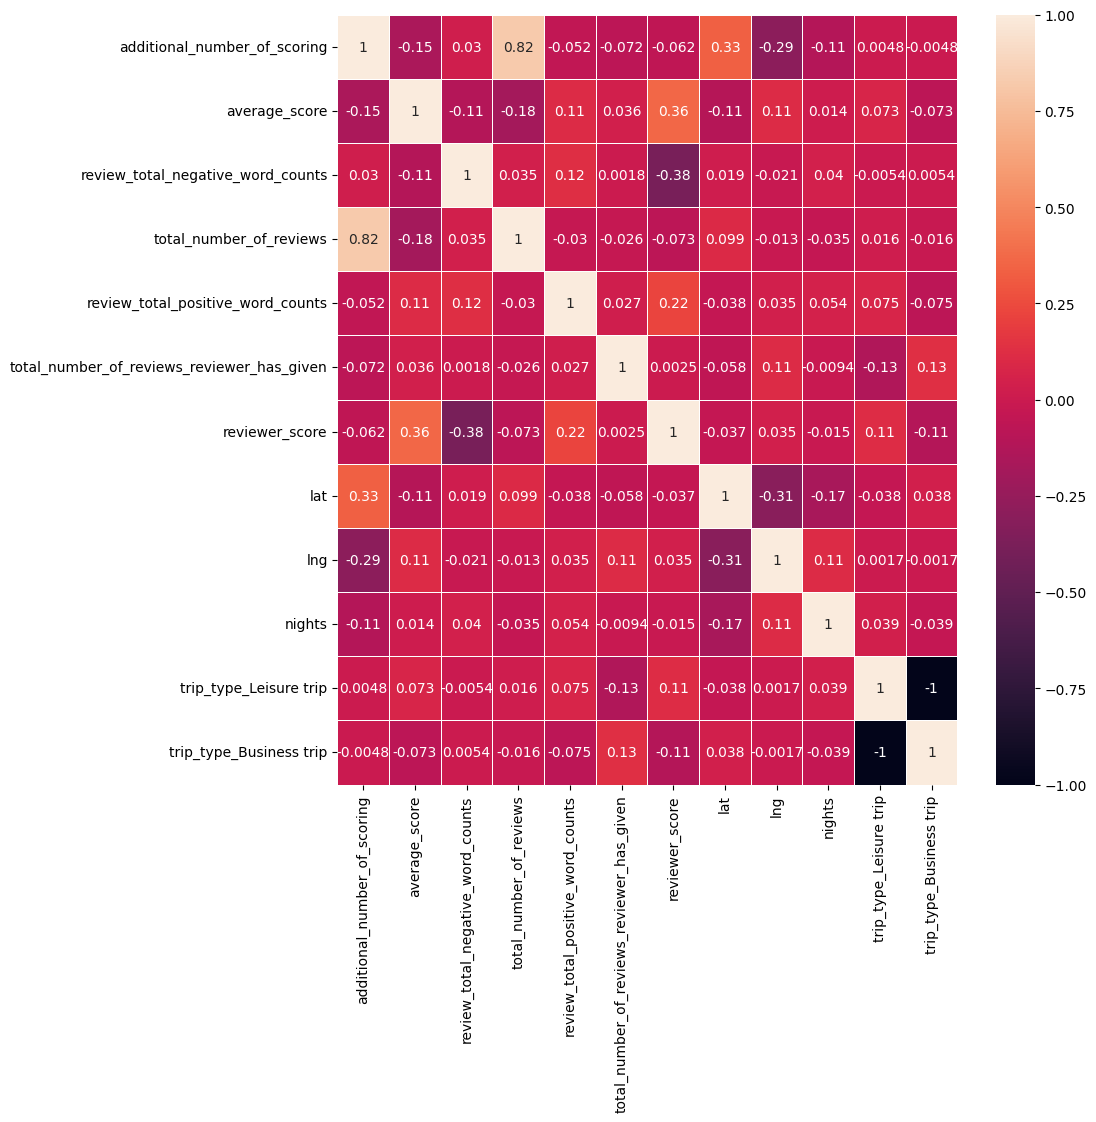

In [37]:
fig, ax = plt.subplots(figsize=(10,10))
sns.heatmap(hotels.corr(numeric_only=True), annot=True, linewidths=.5, ax=ax)

In [38]:
hotels.drop(['additional_number_of_scoring'], axis=1, inplace=True)

In [39]:
hotels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 386803 entries, 0 to 386802
Data columns (total 11 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   average_score                               386803 non-null  float64
 1   review_total_negative_word_counts           386803 non-null  int64  
 2   total_number_of_reviews                     386803 non-null  int64  
 3   review_total_positive_word_counts           386803 non-null  int64  
 4   total_number_of_reviews_reviewer_has_given  386803 non-null  int64  
 5   reviewer_score                              386803 non-null  float64
 6   lat                                         386803 non-null  float64
 7   lng                                         386803 non-null  float64
 8   nights                                      386803 non-null  float64
 9   trip_type_Leisure trip                      386803 non-null  int64  
 

In [40]:
# непрерывные признаки
num_cols = ['total_number_of_reviews', 'review_total_negative_word_counts', 'review_total_positive_word_counts', 'total_number_of_reviews_reviewer_has_given',]

# категориальные признаки
cat_cols = ['average_score', 'lat', 'lng', 'nights', 'trip_type_Leisure trip', 'trip_type_Business trip']

In [41]:
# Разбиваем датафрейм на части, необходимые для обучения и тестирования модели  
# Х - данные с информацией об отелях, у - целевая переменная (рейтинги отелей)  
X = hotels.drop(['reviewer_score'], axis = 1)  
y = hotels['reviewer_score'] 

In [42]:
# Загружаем специальный инструмент для разбивки:  
from sklearn.model_selection import train_test_split  

In [43]:
# Наборы данных с меткой "train" будут использоваться для обучения модели, "test" - для тестирования.  
# Для тестирования мы будем использовать 25% от исходного датасета.  
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [44]:
# Импортируем необходимые библиотеки:  
from sklearn.ensemble import RandomForestRegressor # инструмент для создания и обучения модели  
from sklearn import metrics # инструменты для оценки точности модели  
  
# Создаём модель  
regr = RandomForestRegressor(n_estimators=100)  
      
# Обучаем модель на тестовом наборе данных  
regr.fit(X_train, y_train)  
      
# Используем обученную модель для предсказания рейтинга отелей в тестовой выборке.  
# Предсказанные значения записываем в переменную y_pred  
y_pred = regr.predict(X_test)  

In [45]:
y=y.astype('int')

In [47]:
for col in cat_cols:
    if (X[col] < 0).any():
        print(f"Column {col} contains negative values. Please preprocess the data to make it non-negative.")
        # Пример преобразования отрицательных значений в положительные (замените на свой метод)
        X[col] = X[col].abs()

Column lng contains negative values. Please preprocess the data to make it non-negative.


<Axes: >

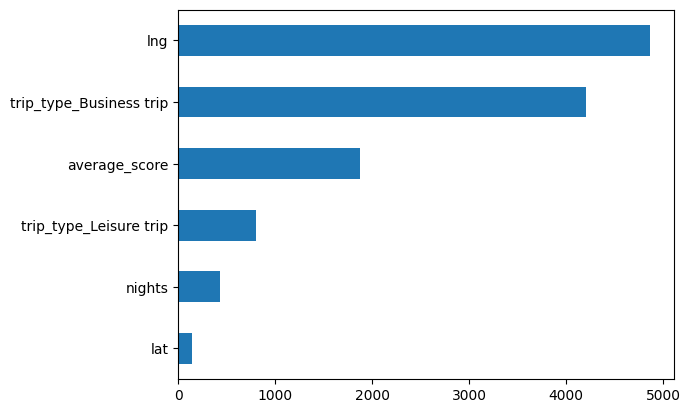

In [48]:
imp_cat = pd.Series(chi2(X[cat_cols], y)[0], index=cat_cols)
imp_cat.sort_values(inplace = True)
imp_cat.plot(kind = 'barh')

In [49]:
print('MAPE:', metrics.mean_absolute_percentage_error(y_test, y_pred))

MAPE: 0.13904016595071977
